<a href="https://colab.research.google.com/github/anshulkr69/learning-to-make-machine-learn/blob/main/5_Feature_Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Feature Scaling (Standardization and Normalization)
technique to standardize the independent features in the data in a fixed range.

### Why needed?
KNN mein distance ke basis pe prediction krta h do agar higher scale mein data hoga toh wo distance jyada btayega but agar scale standardized h then KNN will perform very effectively.

### IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **STANDARDIZATION**
aka Z-Score Normalization

$z = \frac{x - \mu}{\sigma}$

z: The standardized score

x: The original data value

μ: The mean of the dataset

σ: The standard deviation of the dataset

The Z becomes the new data and when we apple this to every observation of a single independent variable then the `mean` of the new data becomes `zero` (***mean centering***) and `standard devation` becomes `one` (***Squeezing***).



In [18]:
df= pd.read_csv('/content/drive/MyDrive/Datasets/Social_Network_Ads.csv')

In [19]:
df=df.iloc[:,2:] #the other columns are not needed

In [20]:
df.sample(5)

,Age,EstimatedSalary,Purchased
64,59,83000,0
279,50,36000,1
16,47,25000,1
130,31,58000,0
108,26,86000,0


## Train Test split

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)
x_train.shape, x_test.shape

((280, 2), (120, 2))

In [25]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

#to calculate mean and std dev.
scaler.fit(x_train)

# transform train and test sets
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test) #isko bhi training data se hi standardize krte hain
# This return list and not a DF

In [27]:
# so we convert it to df
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [34]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [37]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


## Effect of Scaling

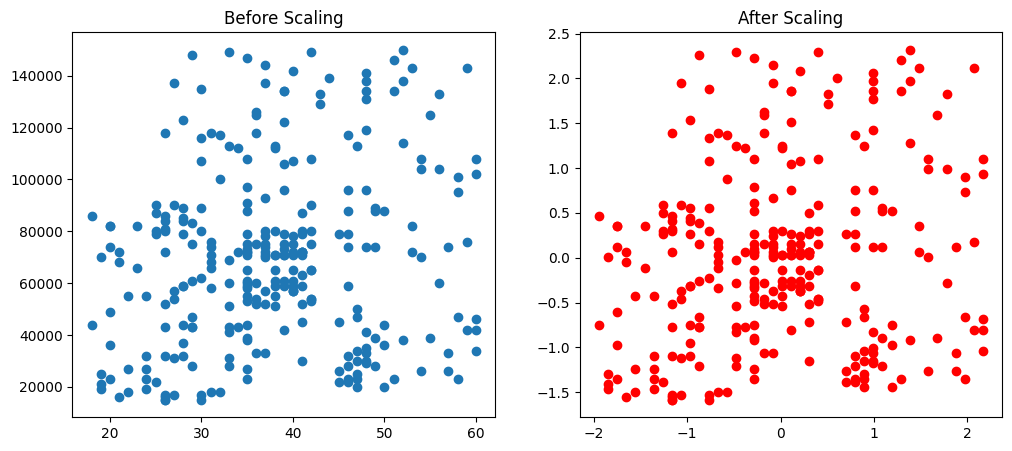

In [41]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

we can see that there is now change in how the datapoints are arranged, the still share the same correlation, its just mean centred and squeezed.

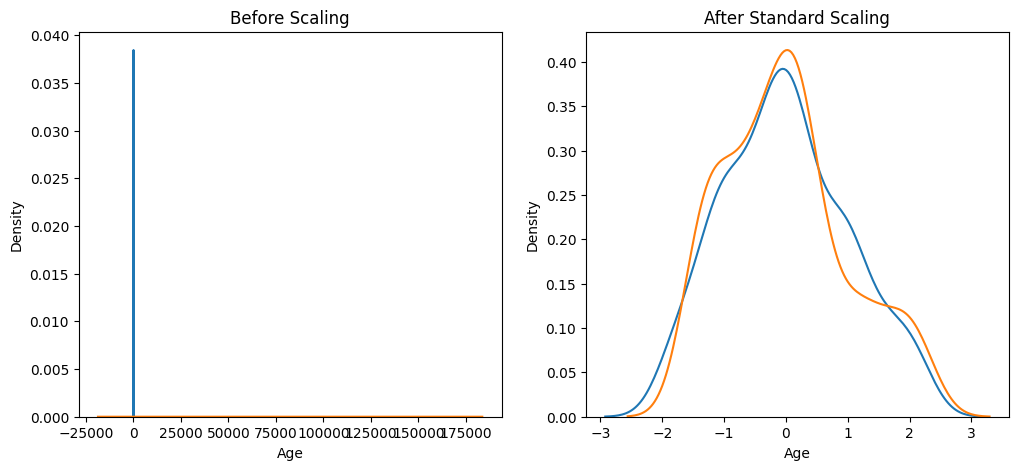

In [43]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

## Comparision of distributions

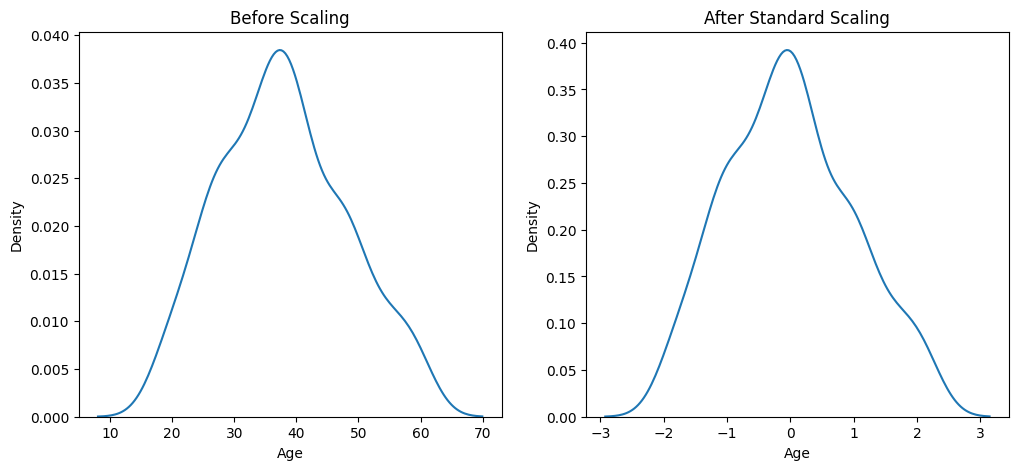

In [45]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
plt.show()

/tmp/ipykernel_17581/320875256.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


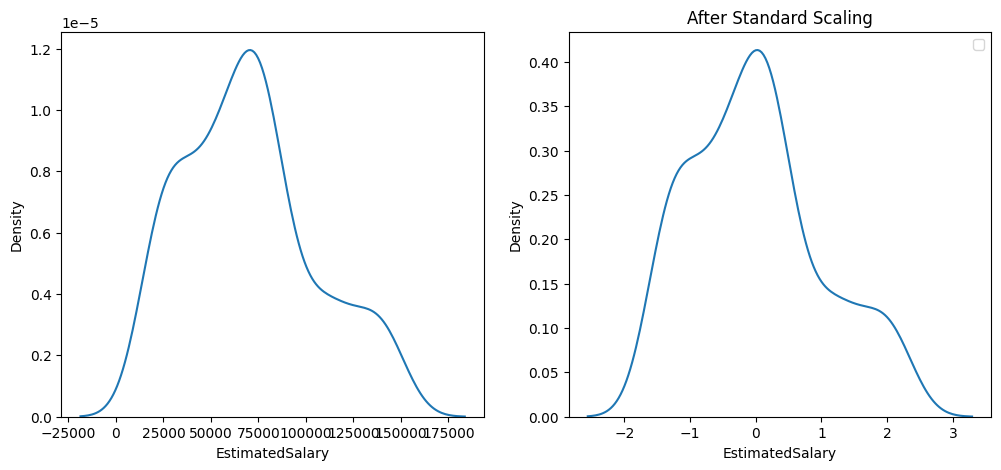

In [47]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling

sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')

sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

It is clearly evident that the distribution doesn't change even after scaling the data through standardization.

In [48]:
from sklearn.linear_model import LogisticRegression

In [51]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [52]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

LogisticRegression()

In [54]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [55]:
from sklearn.metrics import accuracy_score

In [56]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


The accurace on the unscaled data is unpredictable and is dependent on how python handles data so the accuracy of unscaled data back when CampusX made video was around 65% but now its 87.5 bcoz of how data is handled but the Scaled accuracy remains same.

**KNN MEIN KARNE SE SCALED MEIN PAKKA JYADA ACCURACY AYEGA!!!**

# **NORMALIZATION**

TYPES:
1. MinMaxScaling
2. Mean normalization
3. Max absolute
4. Robust scaling

###1. MinMaxScaling:
$$X_{\text{new}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}$$
Range => [0,1]

In [18]:
df=pd.read_csv('/content/drive/MyDrive/Datasets/wine_data.csv',header=None, usecols=[0,1,2])

In [20]:

df.shape

(178, 3)

In [21]:
df.columns=['Class Label','Alcohol','Malic acid']
df.head(5)

,Class Label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Malic acid', ylabel='Density'>

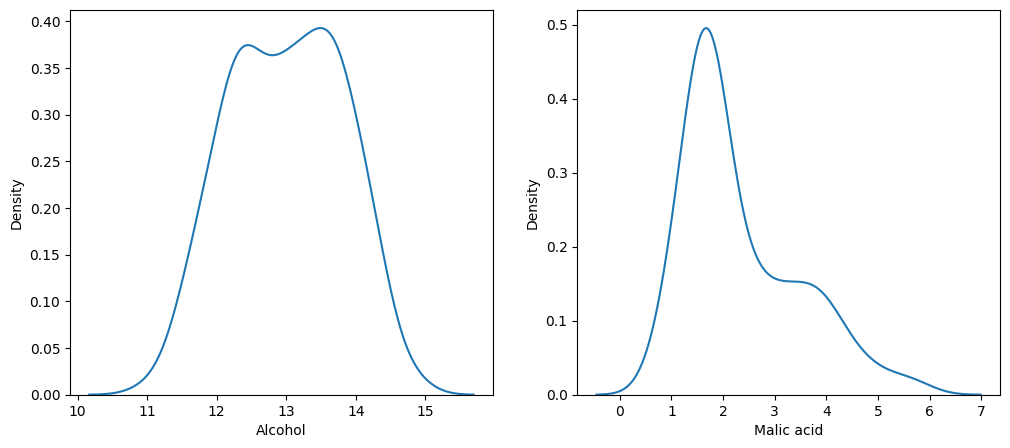

In [22]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(df['Alcohol'], ax=ax1)
sns.kdeplot(df['Malic acid'], ax=ax2)

In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(df.drop('Class Label', axis=1),df['Class Label'],test_size=0.3,random_state=0)
x_train.shape, x_test.shape

((124, 2), (54, 2))

In [26]:
x_train

,Alcohol,Malic acid
22,13.71,1.86
108,12.22,1.29
175,13.27,4.28
145,13.16,3.57
71,13.86,1.51
...,...,...
103,11.82,1.72
67,12.37,1.17
117,12.42,1.61
47,13.90,1.68


In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

scaler.fit(x_train)

x_train_scaled= scaler.transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [34]:
x_train_scaled=pd.DataFrame(x_train_scaled, columns= x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled, columns=x_train.columns)

In [35]:
x_train.describe()

,Alcohol,Malic acid
count,124.000000,124.000000
mean,12.983065,2.383710
std,0.801340,1.136696
min,11.030000,0.890000
25%,12.362500,1.607500
50%,13.040000,1.885000
75%,13.640000,3.247500
max,14.750000,5.650000


In [36]:
x_train_scaled.describe()

,Alcohol,Malic acid
count,124.000000,124.000000
mean,0.525017,0.313805
std,0.215414,0.238802
min,0.000000,0.000000
25%,0.358199,0.150735
50%,0.540323,0.209034
75%,0.701613,0.495273
max,1.000000,1.000000


<Axes: title={'center': 'After'}, xlabel='Alcohol', ylabel='Density'>

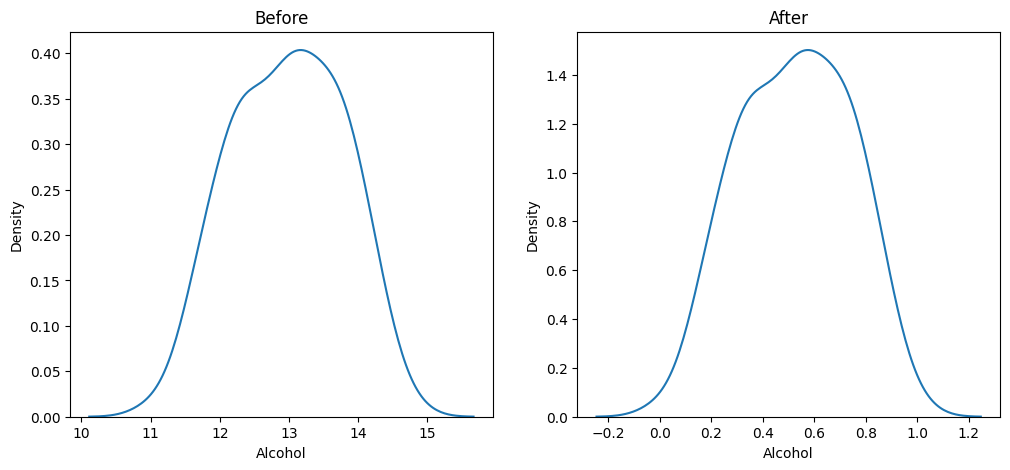

In [38]:
fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(12,5))
ax1.set_title('Before')
sns.kdeplot(x_train['Alcohol'], ax=ax1)
ax2.set_title('After')
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)

# PS: the shape of the distribution can change is some cases!!

### 2. Mean normalization
$x' = \frac{x - \mu}{\max(x) - \min(x)}$

where:

$\mu$ (or $\text{mean}(x)$) is the average value of the feature.

$x_{\max}$ is the maximum value of the feature.

$x_{\min}$ is the minimum value of the feature.

>-Mean centering is done in this one.

>-used when data needs to be centred

>-gives both +ve and -ve values

### 3. MaxAbsScaling
$x' = \frac{x - \mu}{\max(x) - \min(x)}$

Where:

$\mu$ (or $\text{mean}(x)$) is the average value of the feature.

$x_{\max}$ is the maximum value of the feature.

$x_{\min}$ is the minimum value of the feature.

> -used when the data is sparse (many zeros)

### 4. Robust scaling
$x' = \frac{x - \text{med}}{IQR}$

Where:

$\text{median}(x)$ is the median (50th percentile) of the feature.

$Q_1(x)$ is the 25th percentile (1st quartile) of the feature.

$Q_3(x)$ is the 75th percentile (3rd quartile) of the feature.

$Q_3(x) - Q_1(x)$ represents the Interquartile Range ($\text{IQR}$).

> -It is robust to outliers so works flawlessly when outliers are present in the data

# NORMALIZATION vs STANDARDIZATION
-Is feature scaling required?

-Which one to use?
>mostly StandardScaler() class is used but MaxMin is used when we know the max and min of the data already. CNN eg. given by CampusX.

`NOTE: Use every scaling technique as a beginner!!`

F*ck around and figure out ;)